## 4. Preprocessing and Performance: Detecting Exoplanets

# Assignment 4 — Detecting Exoplanets

In this assignment I work with exoplanet data from the Kepler/K2 mission.

The goal is to classify observations into exoplanet-related classes based on features.

This is a supervised classification problem. In my final version, I use three target classes:
- 0 = false positive / non-exoplanet
- 1 = candidate
- 2 = confirmed exoplanet

Main focus:
- data exploration
- missing values
- outlier analysis
- feature selection
- feature transformation
- scaling
- train/validation/test split
- Logistic Regression
- Support Vector Machine
- confusion matrix and classification metrics

**Data Source**: The dataset is provided by the NASA Exoplanet Archive, NASA Exoplanet Science Institute [here](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=koi). There are several datasets available, all from differet periods, but we will use the __Cumulative KOI Data__ dataset.

The cumulative KOI (Kepler Objects of interest) table gathers information from the individual KOI activity tables that describe the current results of different searches of the Kepler light curves. The intent of the cumulative table is to provide the most accurate dispositions and stellar and planetary information for all KOIs in one place. All the information in this table has provenance in other KOI activity tables (_exoplanetarchive.ipac.caltech.edu, 2018_).

The data has been locally downloaded and saved as `exoplanet_dataset.csv`.


### 1. Explore

In [1]:
# Loading the data (change this if you want other var-names, etc.)
import pandas as pd
exoplanet_df = pd.read_csv('exoplanet_dataset.csv')

print(exoplanet_df.shape, "- 9564 rows with 49 features")

pd.set_option('display.max_columns', None)
exoplanet_df.head()

(9564, 49) - 9564 rows with 49 features


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,NaN,NaN,93.59,29.45,-16.65,35.8,1.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,NaN,NaN,9.11,2.87,-1.62,25.8,2.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,NaN,NaN,39.30,31.04,-10.49,76.3,1.0,q1_q17_dr25_tce,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,NaN,NaN,891.96,668.95,-230.35,505.6,1.0,q1_q17_dr25_tce,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,NaN,NaN,926.16,874.33,-314.24,40.9,1.0,q1_q17_dr25_tce,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


**COLUMN NAME | COLUMN DESCRIPTION [Data measurement unit type]**

COLUMN kepid:          KepID <br/>
COLUMN kepoi_name:     KOI Name <br/>
COLUMN kepler_name:    Kepler Name <br/>
COLUMN koi_disposition: Exoplanet Archive Disposition <br/>
COLUMN koi_pdisposition: Disposition Using Kepler Data <br/>
COLUMN koi_score:      Disposition Score <br/>
COLUMN koi_fpflag_nt:  Not Transit-Like False Positive Flag <br/>
COLUMN koi_fpflag_ss:  Stellar Eclipse False Positive Flag <br/>
COLUMN koi_fpflag_co:  Centroid Offset False Positive Flag <br/>
COLUMN koi_fpflag_ec:  Ephemeris Match Indicates Contamination False Positive Flag <br/>
COLUMN koi_period:     Orbital Period [days] <br/>
COLUMN koi_period_err1: Orbital Period Upper Unc. [days] <br/>
COLUMN koi_period_err2: Orbital Period Lower Unc. [days] <br/>
COLUMN koi_time0bk:    Transit Epoch [BKJD] <br/>
COLUMN koi_time0bk_err1: Transit Epoch Upper Unc. [BKJD] <br/>
COLUMN koi_time0bk_err2: Transit Epoch Lower Unc. [BKJD] <br/>
COLUMN koi_impact:     Impact Parameter <br/>
COLUMN koi_impact_err1: Impact Parameter Upper Unc. <br/>
COLUMN koi_impact_err2: Impact Parameter Lower Unc. <br/>
COLUMN koi_duration:   Transit Duration [hrs] <br/>
COLUMN koi_duration_err1: Transit Duration Upper Unc. [hrs] <br/>
COLUMN koi_duration_err2: Transit Duration Lower Unc. [hrs] <br/>
COLUMN koi_depth:      Transit Depth [ppm] <br/>
COLUMN koi_depth_err1: Transit Depth Upper Unc. [ppm] <br/>
COLUMN koi_depth_err2: Transit Depth Lower Unc. [ppm] <br/>
COLUMN koi_prad:       Planetary Radius [Earth radii] <br/>
COLUMN koi_prad_err1:  Planetary Radius Upper Unc. [Earth radii] <br/>
COLUMN koi_prad_err2:  Planetary Radius Lower Unc. [Earth radii] <br/>
COLUMN koi_teq:        Equilibrium Temperature [K] <br/>
COLUMN koi_teq_err1:   Equilibrium Temperature Upper Unc. [K] <br/>
COLUMN koi_teq_err2:   Equilibrium Temperature Lower Unc. [K] <br/>
COLUMN koi_insol:      Insolation Flux [Earth flux] <br/>
COLUMN koi_insol_err1: Insolation Flux Upper Unc. [Earth flux] <br/>
COLUMN koi_insol_err2: Insolation Flux Lower Unc. [Earth flux] <br/>
COLUMN koi_model_snr:  Transit Signal-to-Noise <br/>
COLUMN koi_tce_plnt_num: TCE Planet Number <br/>
COLUMN koi_tce_delivname: TCE Delivery <br/>
COLUMN koi_steff:      Stellar Effective Temperature [K] <br/>
COLUMN koi_steff_err1: Stellar Effective Temperature Upper Unc. [K] <br/>
COLUMN koi_steff_err2: Stellar Effective Temperature Lower Unc. [K] <br/>
COLUMN koi_slogg:      Stellar Surface Gravity [log10(cm/s^2)] <br/>
COLUMN koi_slogg_err1: Stellar Surface Gravity Lower Unc. [log10(cm/s^2)] <br/>
COLUMN koi_slogg_err2: Stellar Surface Gravity Lower Unc. [log10(cm/s^2)] <br/>
COLUMN koi_srad:       Stellar Radius [Solar radii] <br/>
COLUMN koi_srad_err1:  Stellar Radius Upper Unc. [Solar radii] <br/>
COLUMN koi_srad_err2:  Stellar Radius Lower Unc. [Solar radii] <br/>
COLUMN ra:             RA [decimal degrees] <br/>
COLUMN dec:            Dec [decimal degrees] <br/>
COLUMN koi_kepmag:     Kepler-band [mag] <br/>

In [2]:
# For an easier comprehension, we will rename the columns into their description.

exoplanet_df = exoplanet_df.rename(columns={'kepid':'KepID',
'kepoi_name':'KOIName',
'kepler_name':'KeplerName',
'koi_disposition':'ExoplanetArchiveDisposition',
'koi_pdisposition':'DispositionUsingKeplerData',
'koi_score':'DispositionScore',
'koi_fpflag_nt':'NotTransit-LikeFalsePositiveFlag',
'koi_fpflag_ss':'koi_fpflag_ss',
'koi_fpflag_co':'CentroidOffsetFalsePositiveFlag',
'koi_fpflag_ec':'EphemerisMatchIndicatesContaminationFalsePositiveFlag',
'koi_period':'OrbitalPeriod, days',
'koi_period_err1':'OrbitalPeriodUpperUnc, days',
'koi_period_err2':'OrbitalPeriodLowerUnc, days',
'koi_time0bk':'TransitEpoch, BKJD',
'koi_time0bk_err1':'TransitEpochUpperUnc, BKJD',
'koi_time0bk_err2':'TransitEpochLowerUnc, BKJD',
'koi_impact':'ImpactParamete',
'koi_impact_err1':'ImpactParameterUpperUnc',
'koi_impact_err2':'ImpactParameterLowerUnc',
'koi_duration':'TransitDuration, hrs',
'koi_duration_err1':'TransitDurationUpperUnc, hrs',
'koi_duration_err2':'TransitDurationLowerUnc, hrs',
'koi_depth':'TransitDepth, ppm',
'koi_insol':'InsolationFlux, Earthflux',
'koi_insol_err1':'InsolationFluxUpperUnc, Earthflux',
'koi_insol_err2':'InsolationFluxLowerUnc, Earthflux',
'koi_model_snr':'TransitSignal-to-Noise',
'koi_tce_plnt_num':'TCEPlanetNumber',
'koi_tce_delivname':'TCEDeliver',
'koi_steff':'StellarEffectiveTemperature, K',
'koi_steff_err1':'StellarEffectiveTemperatureUpperUnc, K',
'koi_steff_err2':'StellarEffectiveTemperatureLowerUnc, K',
'koi_depth_err1':'TransitDepthUpperUnc, ppm',
'koi_depth_err2':'TransitDepthLowerUnc, ppm',
'koi_prad':'PlanetaryRadius, Earthradii',
'koi_prad_err1':'PlanetaryRadiusUpperUnc, Earthradii',
'koi_prad_err2':'PlanetaryRadiusLowerUnc, Earthradii',
'koi_teq':'EquilibriumTemperature, K',
'koi_teq_err1':'EquilibriumTemperatureUpperUnc, K',
'koi_teq_err2':'EquilibriumTemperatureLowerUnc, K',
'koi_slogg':'StellarSurfaceGravity, log10(cm/s^2)',
'koi_slogg_err1':'StellarSurfaceGravityUpperUnc, log10(cm/s^2)',
'koi_slogg_err2':'StellarSurfaceGravityLowerUnc, log10(cm/s^2)',
'koi_srad':'StellarRadius, Solarradii',
'koi_srad_err1':'StellarRadiusUpperUnc, Solarradii',
'koi_srad_err2':'StellarRadiusLowerUnc, Solarradii',
'ra':'RA, decimaldegrees',
'dec':'Dec, decimaldegrees',
'koi_kepmag':'Kepler-band, mag'
})

**Updated data type value analysis**

In [3]:
exoplanet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 49 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   KepID                                                  9564 non-null   int64  
 1   KOIName                                                9564 non-null   str    
 2   KeplerName                                             2673 non-null   str    
 3   ExoplanetArchiveDisposition                            9564 non-null   str    
 4   DispositionUsingKeplerData                             9564 non-null   str    
 5   DispositionScore                                       8054 non-null   float64
 6   NotTransit-LikeFalsePositiveFlag                       9564 non-null   int64  
 7   koi_fpflag_ss                                          9564 non-null   int64  
 8   CentroidOffsetFalsePositiveFlag                        9564

#### Description of some of the features

Given that some of the features might not be as straightforward going by their names, here are some descriptions for some of them, taken from the [Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html).

`DispositionScore` - A value between 0 and 1 that indicates the confidence in the KOI disposition. For CANDIDATEs, a higher value indicates more confidence in its disposition, while for FALSE POSITIVEs, a higher value indicates less confidence in that disposition. The value is calculated from a Monte Carlo technique such that the score's value is equivalent to the fraction of iterations where the Robovetter yields a disposition of CANDIDATE.

`NotTransit-LikeFlag` A KOI whose light curve is not consistent with that of a transiting planet. This includes, but is not limited to, instrumental artifacts, non-eclipsing variable stars, and spurious (very low SNR) detections.	

`StellarEclipseFlag` A KOI that is observed to have a significant secondary event, transit shape, or out-of-eclipse variability, which indicates that the transit-like event is most likely caused by an eclipsing binary. However, self-luminous, hot Jupiters with a visible secondary eclipse will also have this flag set, but with a disposition of PC.

`Centroid Offset Flag` The source of the signal is from a nearby star, as inferred by measuring the centroid location of the image both in and out of transit, or by the strength of the transit signal in the target's outer (halo) pixels as compared to the transit signal from the pixels in the optimal (or core) aperture.

`EphemerisMatchIndicatesContaminationFlag` The KOI shares the same period and epoch as another object and is judged to be the result of flux contamination in the aperture or electronic crosstalk.

`Upper/LowerUnc` Uncertainties Columns(positive +)(negative -) aka - the error range for the columns. 

`TransitEpoch`	The time corresponding to the center of the first detected transit in Barycentric Julian Day (BJD).

`ImpactParameter`	The sky-projected distance between the center of the stellar disc and the center of the planet disc at conjunction, normalized by the stellar radius.

`TransitDepth` (parts per million)	The fraction of stellar flux lost at the minimum of the planetary transit. Transit depths are typically computed from a best-fit model produced by a Mandel-Agol (2002) model fit to a multi-quarter Kepler light curve, assuming a linear orbital ephemeris.

`InsolationFlux` [Earth flux]	Insolation flux is another way to give the equilibrium temperature. It depends on the stellar parameters (specifically the stellar radius and temperature), and on the semi-major axis of the planet. It's given in units relative to those measured for the Earth from the Sun.

`Equilibrium Temperature` (Kelvin)	Approximation for the temperature of the planet. The calculation of equilibrium temperature assumes a) thermodynamic equilibrium between the incident stellar flux and the radiated heat from the planet, b) a Bond albedo (the fraction of total power incident upon the planet scattered back into space) of 0.3, c) the planet and star are blackbodies, and d) the heat is evenly distributed between the day and night sides of the planet.

`RA` Right ascension (abbreviated RA; symbol α) is the angular distance of a particular point measured eastward along the celestial equator from the Sun at the March equinox to the (hour circle of the) point in question above the earth.

`Dec` declination (abbreviated dec; symbol δ) is one of the two angles that locate a point on the celestial sphere in the equatorial coordinate system, the other being hour angle. 

#### Target identification and modelling

The dataset contains two disposition columns:

- `DispositionUsingKeplerData`: contains `CANDIDATE` and `FALSE POSITIVE`
- `ExoplanetArchiveDisposition`: contains `FALSE POSITIVE`, `CANDIDATE` and `CONFIRMED`

In this notebook I use `ExoplanetArchiveDisposition` as the final target, mapped into three classes:

- 0 = FALSE POSITIVE
- 1 = CANDIDATE
- 2 = CONFIRMED

Because there are three possible target classes, this is a multiclass classification problem

DispositionUsingKeplerData
FALSE POSITIVE    4847
CANDIDATE         4717
Name: count, dtype: int64


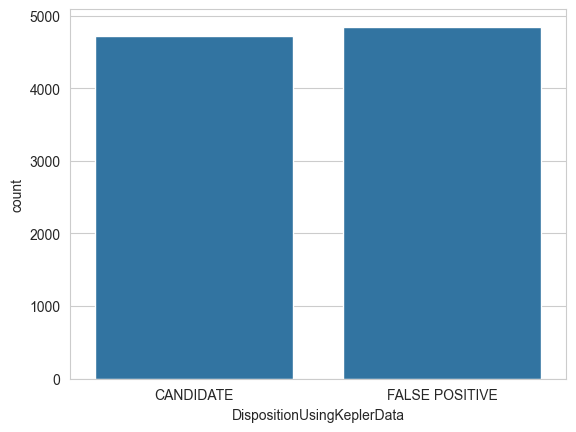

In [4]:
import seaborn as sns
sns.countplot(x = exoplanet_df['DispositionUsingKeplerData'])
print(exoplanet_df['DispositionUsingKeplerData'].value_counts())

ExoplanetArchiveDisposition
FALSE POSITIVE    4839
CONFIRMED         2671
CANDIDATE         2054
Name: count, dtype: int64


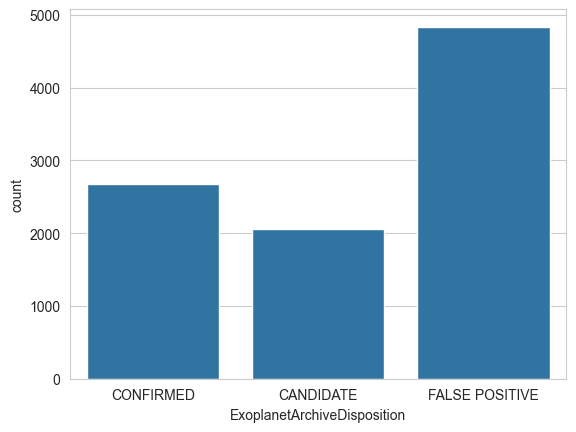

In [5]:
sns.countplot(x= exoplanet_df['ExoplanetArchiveDisposition'])
print(exoplanet_df['ExoplanetArchiveDisposition'].value_counts())

In [6]:
missing_percent = (exoplanet_df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent

EquilibriumTemperatureUpperUnc, K                        100.000000
EquilibriumTemperatureLowerUnc, K                        100.000000
KeplerName                                                72.051443
DispositionScore                                          15.788373
StellarEffectiveTemperatureLowerUnc, K                     5.050188
StellarRadiusUpperUnc, Solarradii                          4.893350
StellarEffectiveTemperatureUpperUnc, K                     4.893350
StellarSurfaceGravityLowerUnc, log10(cm/s^2)               4.893350
StellarSurfaceGravityUpperUnc, log10(cm/s^2)               4.893350
StellarRadiusLowerUnc, Solarradii                          4.893350
TransitEpochUpperUnc, BKJD                                 4.746968
OrbitalPeriodUpperUnc, days                                4.746968
OrbitalPeriodLowerUnc, days                                4.746968
TransitEpochLowerUnc, BKJD                                 4.746968
ImpactParameterUpperUnc                         

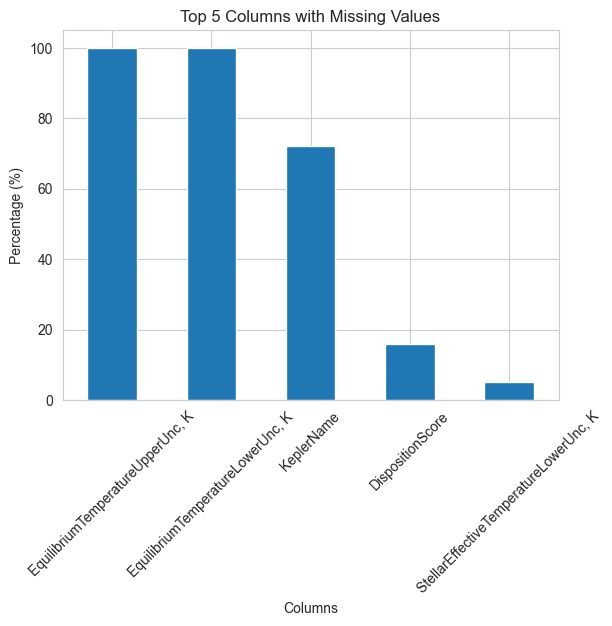

EquilibriumTemperatureUpperUnc, K         100.000000
EquilibriumTemperatureLowerUnc, K         100.000000
KeplerName                                 72.051443
DispositionScore                           15.788373
StellarEffectiveTemperatureLowerUnc, K      5.050188
dtype: float64

In [7]:
import matplotlib.pyplot as plt

top5 = missing_percent.head(5)

plt.figure()
top5.plot(kind="bar")
plt.title("Top 5 Columns with Missing Values")
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.show()
missing_percent.head(5)

![Quantile Wikipedia Image](https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/Iqr_with_quantile.png/500px-Iqr_with_quantile.png)

In [8]:
import numpy as np

numeric_cols = exoplanet_df.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = exoplanet_df[col].quantile(0.25)
    Q3 = exoplanet_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((exoplanet_df[col] < lower_bound) | (exoplanet_df[col] > upper_bound)).sum()

    outlier_summary[col] = outliers

outliers_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outliers Count'])

outliers_df = outliers_df.sort_values(by="Outliers Count", ascending=False)

outliers_df

,Outliers Count
koi_fpflag_ss,2226
CentroidOffsetFalsePositiveFlag,1889
"TransitDepth, ppm",1798
"PlanetaryRadiusUpperUnc, Earthradii",1716
"OrbitalPeriodUpperUnc, days",1650
"OrbitalPeriodLowerUnc, days",1650
TransitSignal-to-Noise,1600
"OrbitalPeriod, days",1567
"InsolationFluxUpperUnc, Earthflux",1536
NotTransit-LikeFalsePositiveFlag,1531


### Feature engineering

In this part I remove irrelevant columns, handle missing values, remove or transform problematic features, encode target labels and prepare the dataset for modelling

![image.png](attachment:image.png)

In [9]:
exoplanet_df.columns

Index(['KepID', 'KOIName', 'KeplerName', 'ExoplanetArchiveDisposition',
       'DispositionUsingKeplerData', 'DispositionScore',
       'NotTransit-LikeFalsePositiveFlag', 'koi_fpflag_ss',
       'CentroidOffsetFalsePositiveFlag',
       'EphemerisMatchIndicatesContaminationFalsePositiveFlag',
       'OrbitalPeriod, days', 'OrbitalPeriodUpperUnc, days',
       'OrbitalPeriodLowerUnc, days', 'TransitEpoch, BKJD',
       'TransitEpochUpperUnc, BKJD', 'TransitEpochLowerUnc, BKJD',
       'ImpactParamete', 'ImpactParameterUpperUnc', 'ImpactParameterLowerUnc',
       'TransitDuration, hrs', 'TransitDurationUpperUnc, hrs',
       'TransitDurationLowerUnc, hrs', 'TransitDepth, ppm',
       'TransitDepthUpperUnc, ppm', 'TransitDepthLowerUnc, ppm',
       'PlanetaryRadius, Earthradii', 'PlanetaryRadiusUpperUnc, Earthradii',
       'PlanetaryRadiusLowerUnc, Earthradii', 'EquilibriumTemperature, K',
       'EquilibriumTemperatureUpperUnc, K',
       'EquilibriumTemperatureLowerUnc, K', 'Insolatio

In [10]:
# Drop the columns with 100% missing values
temp_df = exoplanet_df.drop(columns=['EquilibriumTemperatureUpperUnc, K', 'EquilibriumTemperatureLowerUnc, K',])

# Drop the columns with irrelevant values
clean_exo_df = temp_df.drop(columns=['KeplerName','KepID','KOIName','TCEDeliver'])
clean_exo_df

,ExoplanetArchiveDisposition,DispositionUsingKeplerData,DispositionScore,NotTransit-LikeFalsePositiveFlag,koi_fpflag_ss,CentroidOffsetFalsePositiveFlag,EphemerisMatchIndicatesContaminationFalsePositiveFlag,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","OrbitalPeriodLowerUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD","TransitEpochLowerUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,ImpactParameterLowerUnc,"TransitDuration, hrs","TransitDurationUpperUnc, hrs","TransitDurationLowerUnc, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","PlanetaryRadiusUpperUnc, Earthradii","PlanetaryRadiusLowerUnc, Earthradii","EquilibriumTemperature, K","InsolationFlux, Earthflux","InsolationFluxUpperUnc, Earthflux","InsolationFluxLowerUnc, Earthflux",TransitSignal-to-Noise,TCEPlanetNumber,"StellarEffectiveTemperature, K","StellarEffectiveTemperatureUpperUnc, K","StellarEffectiveTemperatureLowerUnc, K","StellarSurfaceGravity, log10(cm/s^2)","StellarSurfaceGravityUpperUnc, log10(cm/s^2)","StellarSurfaceGravityLowerUnc, log10(cm/s^2)","StellarRadius, Solarradii","StellarRadiusUpperUnc, Solarradii","StellarRadiusLowerUnc, Solarradii","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
0,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,93.59,29.45,-16.65,35.8,1.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,9.11,2.87,-1.62,25.8,2.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,39.30,31.04,-10.49,76.3,1.0,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,891.96,668.95,-230.35,505.6,1.0,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,926.16,874.33,-314.24,40.9,1.0,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,0,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,-0.000170,1.252,0.051,-0.049,3.22210,0.01740,-0.01740,1579.2,4.6,-4.6,29.35,7.70,-2.57,2088.0,4500.53,3406.38,-1175.26,453.3,1.0,5638.0,139.0,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9560,CANDIDATE,CANDIDATE,0.497,0,0,0,0,1.739849,1.780000e-05,-1.780000e-05,133.001270,0.007690,-0.007690,0.043,0.423,-0.043,3.11400,0.22900,-0.22900,48.5,5.4,-5.4,0.72,0.24,-0.08,1608.0,1585.81,1537.86,-502.22,10.6,1.0,6119.0,165.0,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9561,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,0,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,-0.002850,0.147,0.309,-0.147,0.86500,0.16200,-0.16200,103.6,14.7,-14.7,1.07,0.36,-0.11,2218.0,5713.41,5675.74,-1836.94,12.3,1.0,6173.0,193.0,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9562,CANDIDATE,CANDIDATE,0.092,0,0,0,0,333.486169,4.235000e-03,-4.235000e-03,153.615010,0.005070,-

In [11]:
# Due to SVM  and Logical Regression being very sensitive to outliers, we decided to remove them completely
numeric_cols = clean_exo_df.select_dtypes(include=np.number).columns
non_outliers = np.ones(len(clean_exo_df), dtype=bool)

# Impute missing numeric values with median values
medians = clean_exo_df[numeric_cols].median()
clean_exo_df[numeric_cols] = clean_exo_df[numeric_cols].fillna(medians)

# Identify outliers using the IQR method for each numerical column and keep only rows inside the IQR bounds
for col in numeric_cols:
    Q1_clean = clean_exo_df[col].quantile(0.25)
    Q3_clean = clean_exo_df[col].quantile(0.75)
    IQR_clean = Q3_clean - Q1_clean

    lower_bound_clean = Q1_clean - 1.5 * IQR_clean
    upper_bound_clean = Q3_clean + 1.5 * IQR_clean

    non_outliers &= (
        (clean_exo_df[col] >= lower_bound_clean) &
        (clean_exo_df[col] <= upper_bound_clean) |
        clean_exo_df[col].isnull() 
    )

exo_data = clean_exo_df[non_outliers]
clean_numeric_cols = exo_data[numeric_cols]
exo_data

,ExoplanetArchiveDisposition,DispositionUsingKeplerData,DispositionScore,NotTransit-LikeFalsePositiveFlag,koi_fpflag_ss,CentroidOffsetFalsePositiveFlag,EphemerisMatchIndicatesContaminationFalsePositiveFlag,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","OrbitalPeriodLowerUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD","TransitEpochLowerUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,ImpactParameterLowerUnc,"TransitDuration, hrs","TransitDurationUpperUnc, hrs","TransitDurationLowerUnc, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","PlanetaryRadiusUpperUnc, Earthradii","PlanetaryRadiusLowerUnc, Earthradii","EquilibriumTemperature, K","InsolationFlux, Earthflux","InsolationFluxUpperUnc, Earthflux","InsolationFluxLowerUnc, Earthflux",TransitSignal-to-Noise,TCEPlanetNumber,"StellarEffectiveTemperature, K","StellarEffectiveTemperatureUpperUnc, K","StellarEffectiveTemperatureLowerUnc, K","StellarSurfaceGravity, log10(cm/s^2)","StellarSurfaceGravityUpperUnc, log10(cm/s^2)","StellarSurfaceGravityLowerUnc, log10(cm/s^2)","StellarRadius, Solarradii","StellarRadiusUpperUnc, Solarradii","StellarRadiusLowerUnc, Solarradii","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
0,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,0.000028,-0.000028,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.9575,0.0819,-0.0819,615.8,19.50,-19.50,2.26,0.26,-0.15,793.0,93.59,29.45,-16.65,35.8,1.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
4,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,0.000004,-0.000004,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.6545,0.0420,-0.0420,603.3,16.90,-16.90,2.75,0.88,-0.35,1406.0,926.16,874.33,-314.24,40.9,1.0,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,CONFIRMED,CANDIDATE,1.000,0,0,0,0,11.094321,0.000020,-0.000020,171.201160,0.001410,-0.001410,0.538,0.030,-0.428,4.5945,0.0610,-0.0610,1517.5,24.20,-24.20,3.90,1.27,-0.42,835.0,114.81,112.85,-36.70,66.5,1.0,6046.0,189.0,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
18,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.273582,0.000010,-0.000010,173.258155,0.000877,-0.000877,0.387,0.004,-0.386,3.2875,0.0309,-0.0309,1288.3,16.80,-16.80,2.47,0.20,-0.24,649.0,41.85,12.49,-11.70,87.2,1.0,4856.0,131.0,-146.0,4.583,0.065,-0.035,0.696,0.056,-0.068,288.13824,47.724449,15.302
19,CONFIRMED,CANDIDATE,1.000,0,0,0,0,6.029303,0.000006,-0.000006,171.602959,0.000713,-0.000713,0.258,0.196,-0.258,1.5821,0.0311,-0.0311,1912.7,34.40,-34.40,2.85,0.26,-0.15,678.0,50.04,16.40,-9.88,65.4,1.0,4537.0,123.0,-123.0,4.648,0.020,-0.056,0.672,0.062,-0.036,283.71088,47.863270,15.784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9443,CANDIDATE,CANDIDATE,0.998,0,0,0,0,9.464041,0.000280,-0.000280,138.450000,0.022400,-0.022400,0.048,0.420,-0.048,6.9990,0.5630,-0.5630,209.9,25.60,-25.60,1.28,0.37,-0.13,839.0,117.23,100.35,-32.72,9.4,1.0,5968.0,161.0,-179.0,4.534,0.036,-0.204,0.881,0.257,-0.086,286.12177,50.279449,15.807
9505,CANDIDATE,CANDIDATE,0.502,0,0,0,0,5.887704,0.000073,-0.000073,135.037380,0.009710,-0.009710,0.185,0.266,-0.185,4.0090,0.3300,-0.3300,39.7,4.90,-4.90,0.60,0.19,-0.06,1026.0,262.67,251.91,-75.21,9.3,1.0,6065.0,163.0,-181.0,4.495,0.052,-0.221,0.947,0.310,-0.097,293.43494,46.039440,13.811
9514,CANDIDATE,CANDIDATE,0.959,0,0,0,0,1.985146,0.000012,-0.000012,132.026820,0.004790,-0.004790,0.126,0.326,-0.126,1.6250,0.1540,-0.1540,233.4,25.20,-25.20,1.28,0.28,-0.11,1299.0,675.28,446.07,-178.35,11.0,1.0,5581.0,149.0,-166.0,4.559,0.036,-0.153,0.845,0.188,-0.075,282.03058,46.750809,15.988
9517,CANDIDATE,CANDIDATE,0.000,0,0,0,0,1.331993,0.000035,-0.000035,132.647522,0.004130,-0.004130,0.537,0.193,-0.207,4.3300,0.1420,-0.1420,421.1,20.75,-20.75,2.39,0.52,-0.30,878.0,141.60,72.83,-40.26,23.0,1.0,5767.0,1

In [12]:
# Compute correlation
corr_matrix = clean_numeric_cols.corr()

# Stack matrix to long format
stacked = corr_matrix.stack().reset_index()
stacked.columns = ['Feature1', 'Feature2', 'Correlation']

# Take absolute correlations >= 0.5
strong_corr = stacked[
    (stacked['Correlation'].abs() >= 0.70) &
    (stacked['Correlation'].abs() < 1)
]
# Count how many times each feature appears in strong correlations
feature_counts = pd.concat([strong_corr['Feature1']]) \
                   .value_counts()

print(feature_counts)
strong_corr

Feature1
EquilibriumTemperature, K                       3
InsolationFlux, Earthflux                       3
InsolationFluxUpperUnc, Earthflux               3
InsolationFluxLowerUnc, Earthflux               3
StellarSurfaceGravity, log10(cm/s^2)            3
StellarRadiusLowerUnc, Solarradii               3
TransitEpochUpperUnc, BKJD                      2
TransitEpochLowerUnc, BKJD                      2
ImpactParamete                                  2
ImpactParameterUpperUnc                         2
ImpactParameterLowerUnc                         2
TransitDurationUpperUnc, hrs                    2
TransitDurationLowerUnc, hrs                    2
StellarSurfaceGravityUpperUnc, log10(cm/s^2)    2
StellarRadius, Solarradii                       2
StellarRadiusUpperUnc, Solarradii               2
PlanetaryRadius, Earthradii                     1
PlanetaryRadiusLowerUnc, Earthradii             1
StellarEffectiveTemperature, K                  1
StellarEffectiveTemperatureUpperUnc, K   

,Feature1,Feature2,Correlation
384,"TransitEpochUpperUnc, BKJD","TransitDurationUpperUnc, hrs",0.923830
385,"TransitEpochUpperUnc, BKJD","TransitDurationLowerUnc, hrs",-0.923830
425,"TransitEpochLowerUnc, BKJD","TransitDurationUpperUnc, hrs",-0.923830
426,"TransitEpochLowerUnc, BKJD","TransitDurationLowerUnc, hrs",0.923830
463,ImpactParamete,ImpactParameterUpperUnc,-0.765287
464,ImpactParamete,ImpactParameterLowerUnc,-0.937223
503,ImpactParameterUpperUnc,ImpactParamete,-0.765287
505,ImpactParameterUpperUnc,ImpactParameterLowerUnc,0.841987
544,ImpactParameterLowerUnc,ImpactParamete,-0.937223
545,ImpactParameterLowerUnc,ImpactParameterUpperUnc,0.841987


### Removing strongly correlated features
Decided to drop all columns above 80 after hard evaluating the feature

In [13]:
exo_data = exo_data.drop(columns=['TransitEpochLowerUnc, BKJD','OrbitalPeriodLowerUnc, days'
    ,'ImpactParameterLowerUnc','TransitDurationLowerUnc, hrs','InsolationFluxLowerUnc, Earthflux'
    ,'StellarEffectiveTemperatureLowerUnc, K','StellarSurfaceGravityLowerUnc, log10(cm/s^2)','StellarRadiusLowerUnc, Solarradii'
    ,'TransitDurationUpperUnc, hrs','EquilibriumTemperature, K','StellarRadius, Solarradii','InsolationFluxUpperUnc, Earthflux'
    ,'StellarSurfaceGravityUpperUnc, log10(cm/s^2)','StellarRadiusUpperUnc, Solarradii','TransitEpochLowerUnc, BKJD','ImpactParameterLowerUnc'])
exo_data

,ExoplanetArchiveDisposition,DispositionUsingKeplerData,DispositionScore,NotTransit-LikeFalsePositiveFlag,koi_fpflag_ss,CentroidOffsetFalsePositiveFlag,EphemerisMatchIndicatesContaminationFalsePositiveFlag,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,"TransitDuration, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","PlanetaryRadiusUpperUnc, Earthradii","PlanetaryRadiusLowerUnc, Earthradii","InsolationFlux, Earthflux",TransitSignal-to-Noise,TCEPlanetNumber,"StellarEffectiveTemperature, K","StellarEffectiveTemperatureUpperUnc, K","StellarSurfaceGravity, log10(cm/s^2)","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
0,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,0.000028,170.538750,0.002160,0.146,0.318,2.9575,615.8,19.50,-19.50,2.26,0.26,-0.15,93.59,35.8,1.0,5455.0,81.0,4.467,291.93423,48.141651,15.347
4,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,0.000004,171.595550,0.001130,0.701,0.235,1.6545,603.3,16.90,-16.90,2.75,0.88,-0.35,926.16,40.9,1.0,6031.0,169.0,4.438,288.75488,48.226200,15.509
5,CONFIRMED,CANDIDATE,1.000,0,0,0,0,11.094321,0.000020,171.201160,0.001410,0.538,0.030,4.5945,1517.5,24.20,-24.20,3.90,1.27,-0.42,114.81,66.5,1.0,6046.0,189.0,4.486,296.28613,48.224670,15.714
18,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.273582,0.000010,173.258155,0.000877,0.387,0.004,3.2875,1288.3,16.80,-16.80,2.47,0.20,-0.24,41.85,87.2,1.0,4856.0,131.0,4.583,288.13824,47.724449,15.302
19,CONFIRMED,CANDIDATE,1.000,0,0,0,0,6.029303,0.000006,171.602959,0.000713,0.258,0.196,1.5821,1912.7,34.40,-34.40,2.85,0.26,-0.15,50.04,65.4,1.0,4537.0,123.0,4.648,283.71088,47.863270,15.784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9443,CANDIDATE,CANDIDATE,0.998,0,0,0,0,9.464041,0.000280,138.450000,0.022400,0.048,0.420,6.9990,209.9,25.60,-25.60,1.28,0.37,-0.13,117.23,9.4,1.0,5968.0,161.0,4.534,286.12177,50.279449,15.807
9505,CANDIDATE,CANDIDATE,0.502,0,0,0,0,5.887704,0.000073,135.037380,0.009710,0.185,0.266,4.0090,39.7,4.90,-4.90,0.60,0.19,-0.06,262.67,9.3,1.0,6065.0,163.0,4.495,293.43494,46.039440,13.811
9514,CANDIDATE,CANDIDATE,0.959,0,0,0,0,1.985146,0.000012,132.026820,0.004790,0.126,0.326,1.6250,233.4,25.20,-25.20,1.28,0.28,-0.11,675.28,11.0,1.0,5581.0,149.0,4.559,282.03058,46.750809,15.988
9517,CANDIDATE,CANDIDATE,0.000,0,0,0,0,1.331993,0.000035,132.647522,0.004130,0.537,0.193,4.3300,421.1,20.75,-20.75,2.39,0.52,-0.30,141.60,23.0,1.0,5767.0,157.0,4.438,295.20798,46.786221,15.024


In [14]:
# mapping dictionary
mapping = {
    "FALSE POSITIVE": 0,
    "CANDIDATE": 1,
    "CONFIRMED": 2
}

# create new columns
exo_data["KeplerDispositionStatus"] = exo_data["ExoplanetArchiveDisposition"].map(mapping)
exo_data["ArchiveDispositionStatus"] = exo_data["ExoplanetArchiveDisposition"].map(mapping)
# Map binary
exo_data['DispositionUsingKeplerData'] = exo_data['DispositionUsingKeplerData'].replace({'FALSE POSITIVE': 0, 'CANDIDATE': 1}).astype(int)
# drop original columns
exo_data_almost_final = exo_data.drop(columns=["ExoplanetArchiveDisposition", "ExoplanetArchiveDisposition"])

# check result
exo_data_almost_final[["KeplerDispositionStatus", "ArchiveDispositionStatus"]]

,KeplerDispositionStatus,ArchiveDispositionStatus
0,2,2
4,2,2
5,2,2
18,2,2
19,2,2
...,...,...
9443,1,1
9505,1,1
9514,1,1
9517,1,1


In [15]:
# calculate how many duplicate values each column has
def duplicate_stats(df):
    stats = []

    for col in df.columns:
        total = df[col].count()
        duplicates = df[col].duplicated().sum()
        pct = (duplicates / total * 100) if total > 0 else 0

        stats.append({
            "column": col,
            "total_values": total,
            "duplicate_count": duplicates,
            "duplicate_pct": pct
        })

    return pd.DataFrame(stats).sort_values(by="duplicate_pct", ascending=False)
num_cols = exo_data_almost_final.select_dtypes(include=np.number).columns
stats_df = duplicate_stats(exo_data_almost_final[num_cols])
stats_df

,column,total_values,duplicate_count,duplicate_pct
3,koi_fpflag_ss,1921,1920,99.947944
2,NotTransit-LikeFalsePositiveFlag,1921,1920,99.947944
4,CentroidOffsetFalsePositiveFlag,1921,1920,99.947944
5,EphemerisMatchIndicatesContaminationFalsePosit...,1921,1920,99.947944
21,TCEPlanetNumber,1921,1920,99.947944
0,DispositionUsingKeplerData,1921,1919,99.895888
28,KeplerDispositionStatus,1921,1918,99.843831
29,ArchiveDispositionStatus,1921,1918,99.843831
18,"PlanetaryRadiusLowerUnc, Earthradii",1921,1828,95.158771
17,"PlanetaryRadiusUpperUnc, Earthradii",1921,1790,93.180635


### Low-variation features

We check the duplicate counts to see the data variation for numerical colums.
Having low variance with 99% duplicates would only result in model confusion, almost constant just add noise, we decide to drop them

We also drop KeplerDispositionStatus which is our label

In [16]:
exo_data_almost_final2 = exo_data_almost_final.drop(columns=['TCEPlanetNumber', 'CentroidOffsetFalsePositiveFlag','koi_fpflag_ss','EphemerisMatchIndicatesContaminationFalsePositiveFlag','NotTransit-LikeFalsePositiveFlag','KeplerDispositionStatus','DispositionScore','PlanetaryRadiusLowerUnc, Earthradii','PlanetaryRadiusUpperUnc, Earthradii','StellarEffectiveTemperatureUpperUnc, K','ArchiveDispositionStatus','DispositionUsingKeplerData'])
exo_label = exo_data_almost_final['KeplerDispositionStatus']
exo_data_almost_final2

,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,"TransitDuration, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","InsolationFlux, Earthflux",TransitSignal-to-Noise,"StellarEffectiveTemperature, K","StellarSurfaceGravity, log10(cm/s^2)","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
0,9.488036,0.000028,170.538750,0.002160,0.146,0.318,2.9575,615.8,19.50,-19.50,2.26,93.59,35.8,5455.0,4.467,291.93423,48.141651,15.347
4,2.525592,0.000004,171.595550,0.001130,0.701,0.235,1.6545,603.3,16.90,-16.90,2.75,926.16,40.9,6031.0,4.438,288.75488,48.226200,15.509
5,11.094321,0.000020,171.201160,0.001410,0.538,0.030,4.5945,1517.5,24.20,-24.20,3.90,114.81,66.5,6046.0,4.486,296.28613,48.224670,15.714
18,9.273582,0.000010,173.258155,0.000877,0.387,0.004,3.2875,1288.3,16.80,-16.80,2.47,41.85,87.2,4856.0,4.583,288.13824,47.724449,15.302
19,6.029303,0.000006,171.602959,0.000713,0.258,0.196,1.5821,1912.7,34.40,-34.40,2.85,50.04,65.4,4537.0,4.648,283.71088,47.863270,15.784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9443,9.464041,0.000280,138.450000,0.022400,0.048,0.420,6.9990,209.9,25.60,-25.60,1.28,117.23,9.4,5968.0,4.534,286.12177,50.279449,15.807
9505,5.887704,0.000073,135.037380,0.009710,0.185,0.266,4.0090,39.7,4.90,-4.90,0.60,262.67,9.3,6065.0,4.495,293.43494,46.039440,13.811
9514,1.985146,0.000012,132.026820,0.004790,0.126,0.326,1.6250,233.4,25.20,-25.20,1.28,675.28,11.0,5581.0,4.559,282.03058,46.750809,15.988
9517,1.331993,0.000035,132.647522,0.004130,0.537,0.193,4.3300,421.1,20.75,-20.75,2.39,141.60,23.0,5767.0,4.438,295.20798,46.786221,15.024


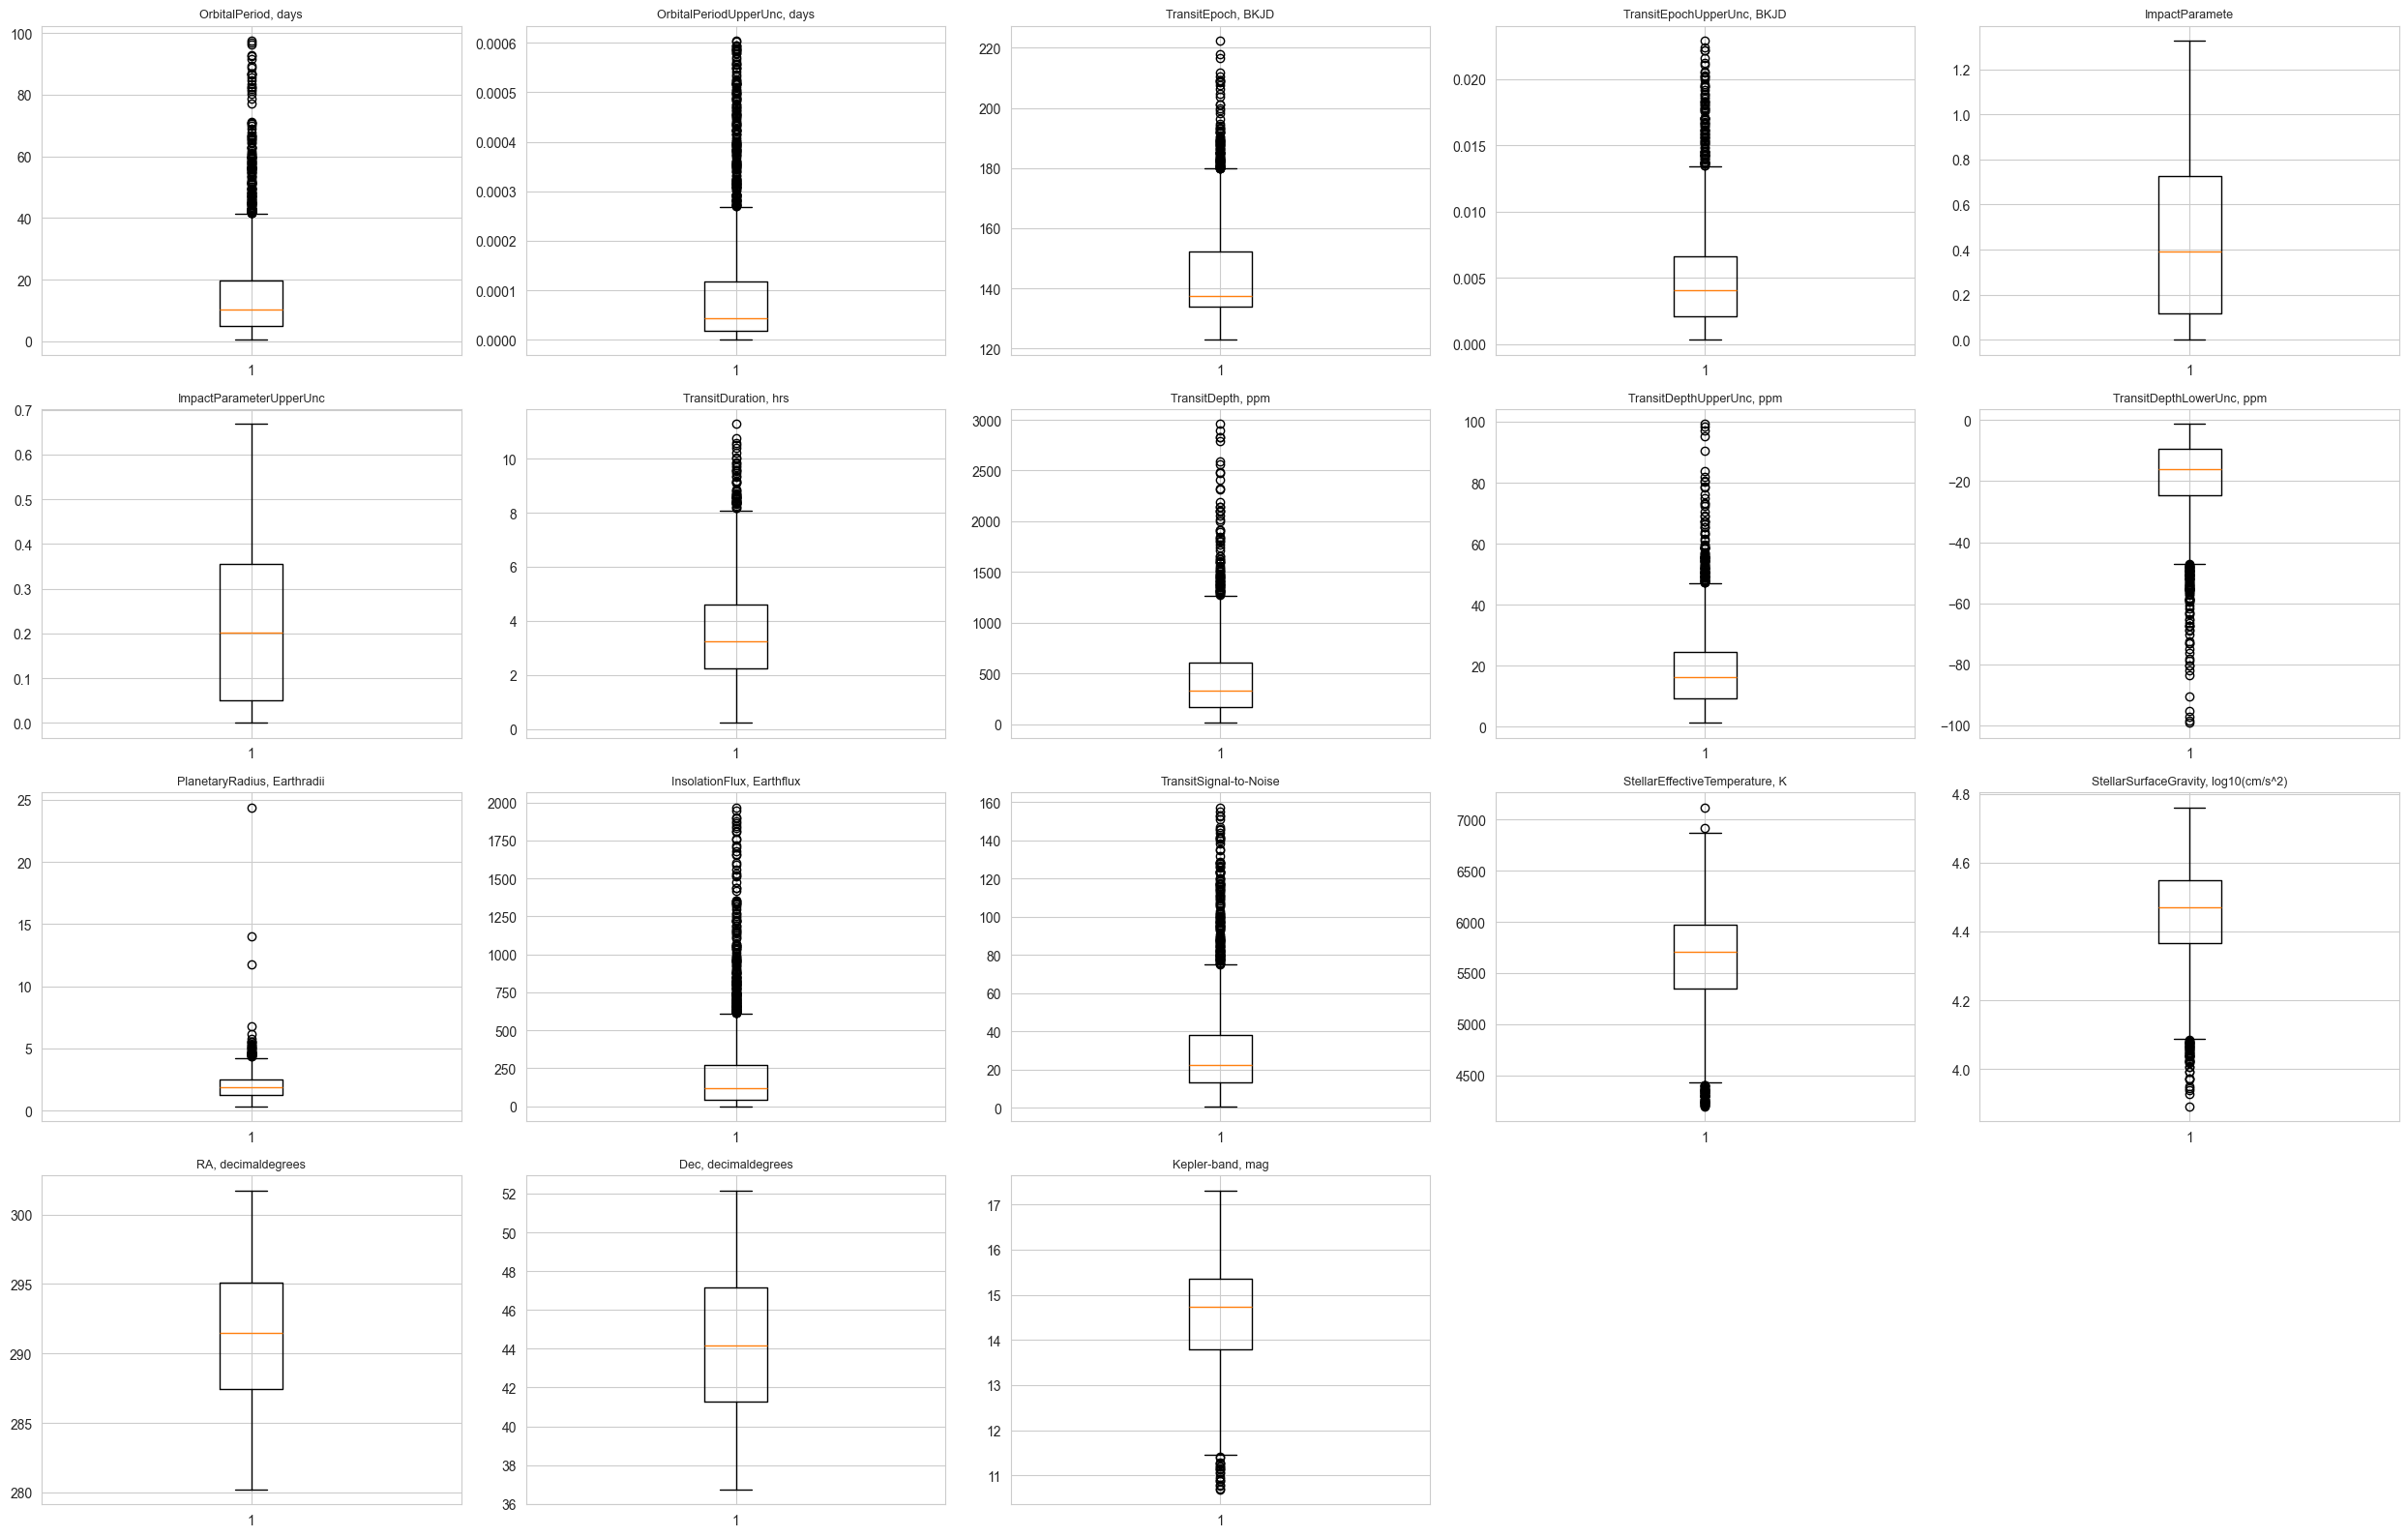

In [17]:
n_cols = 5
numeric_cols = exo_data_almost_final2.select_dtypes(include=np.number).columns
binary_categorical_cols = [
    'KeplerDispositionStatus','ArchiveDispositionStatus','DispositionUsingKeplerData'
]

#Drop the cols that are binary or categorical that we mapped to numeric, as they are not suitable for boxplots
numeric_cols = numeric_cols.drop(binary_categorical_cols, errors='ignore')
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(exo_data_almost_final2[col].dropna())
    plt.title(col, fontsize=9)

plt.tight_layout()
plt.show()

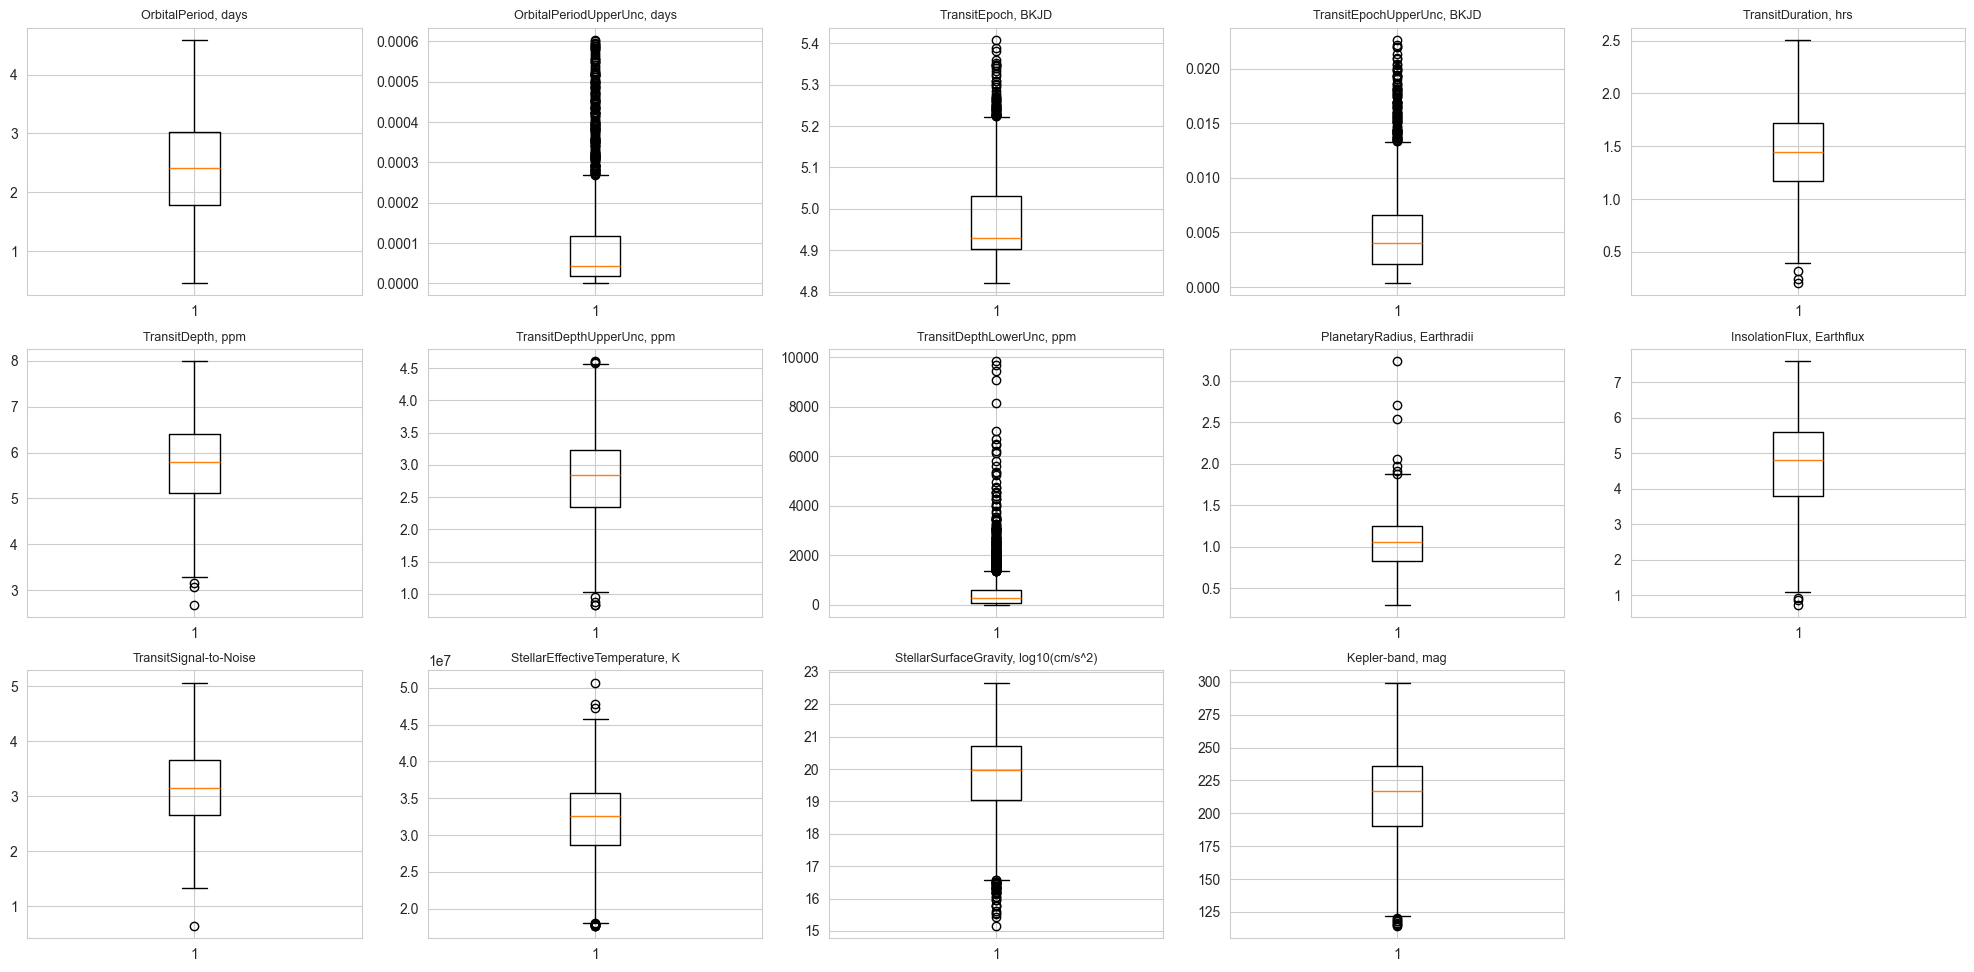

In [18]:
cols_not_skewed = [
    'ImpactParameterUpperUnc',
    'ImpactParamete',
    'StellarEffectiveTemperatureUpperUnc, K',
    'RA, decimaldegrees',
    'Dec, decimaldegrees'
]
left_skewed_cols = [
    'StellarSurfaceGravity, log10(cm/s^2)',
    'Kepler-band, mag','StellarEffectiveTemperature, K',
    'TransitDepthLowerUnc, ppm'
]
skewed_cols = numeric_cols.drop(cols_not_skewed, errors='ignore')
skewed_cols_right = skewed_cols.drop(left_skewed_cols,errors='ignore')

#transform right skewed_cols with log to reduce outliers effect (using log1p.)
exo_data_almost_final2[skewed_cols_right] = exo_data_almost_final2[skewed_cols_right].apply(lambda x: np.log1p(x))

# transform  left-skewed columns using square transformation
exo_data_almost_final2[left_skewed_cols] = exo_data_almost_final2[left_skewed_cols].apply(lambda x: x**2)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(exo_data_almost_final2[col].dropna())
    plt.title(col, fontsize=9)

### 3. Train, Validation and Test Split

I split the data into train, validation and test sets.

The training set is used to train the model.  
The validation set is used to compare models and tune choices.  
The test set is used only once at the end for final evaluation.

I use this split because I want to compare Logistic Regression and SVM before testing the final model on unseen data

In [19]:
from sklearn.model_selection import train_test_split
exo_df_final = exo_data_almost_final2.copy()

X = exo_df_final
y = exo_label

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)
X_train

,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,"TransitDuration, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","InsolationFlux, Earthflux",TransitSignal-to-Noise,"StellarEffectiveTemperature, K","StellarSurfaceGravity, log10(cm/s^2)","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
1886,3.384584,0.000284,4.897248,0.007998,0.695,0.030,1.991157,6.629099,3.725693,1640.25,1.266948,3.154017,3.081910,32626944.0,20.557156,292.23242,38.892220,248.945284
5996,4.397311,0.000391,5.096158,0.004211,0.911,0.024,1.732717,6.790884,3.728100,1648.36,1.444563,1.776646,3.254243,29550096.0,20.295025,282.86319,41.796680,205.062400
862,2.031620,0.000017,5.220290,0.001918,0.111,0.302,1.429162,6.703924,3.122365,470.89,1.264127,5.027755,3.728100,31539456.0,20.511841,287.39200,46.059311,251.000649
710,3.008354,0.000051,5.110687,0.002247,0.548,0.328,1.731815,6.896391,3.113515,462.25,1.396245,3.810433,3.945458,33616804.0,20.313049,286.35806,42.406509,236.175424
2156,2.320665,0.000067,4.905616,0.005495,0.257,0.203,1.671097,4.484132,1.757858,23.04,0.806476,5.672429,3.058707,38365636.0,17.994564,290.99527,45.192211,174.847729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,1.941432,0.000006,4.928402,0.000811,0.166,0.263,1.537082,6.237543,1.840550,28.09,1.449269,6.364579,4.683057,37478884.0,17.413929,294.74207,43.536831,188.156089
6929,3.535256,0.000578,5.013725,0.014100,0.072,0.388,1.387044,5.610936,3.676301,1482.25,0.760806,2.143589,2.208274,24000201.0,21.381376,293.00269,42.708851,217.061289
1257,2.631174,0.000060,5.309405,0.003245,0.082,0.360,1.516226,6.402746,3.335770,734.41,1.075002,3.583241,3.202746,24157225.0,20.358144,294.36487,40.720879,245.674276
8967,1.681198,0.000049,4.889666,0.009009,0.177,0.281,1.155937,4.651099,2.646175,171.61,0.657520,5.794993,2.388763,33907329.0,20.151121,291.93356,38.827202,216.119401


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train

,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,"TransitDuration, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","InsolationFlux, Earthflux",TransitSignal-to-Noise,"StellarEffectiveTemperature, K","StellarSurfaceGravity, log10(cm/s^2)","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
1886,1.122973,1.581341,-0.761546,0.764519,0.810335,-1.175370,1.377159,0.972563,1.378751,1.096602,0.733171,-1.189047,-0.199861,0.165965,0.607734,0.206336,-1.470165,1.244128
5996,2.301055,2.477447,1.033574,-0.193873,1.470264,-1.214197,0.723204,1.149444,1.382343,1.104970,1.328041,-2.252531,0.054908,-0.406972,0.402036,-1.740741,-0.693379,-0.217712
862,-0.450899,-0.641368,2.153837,-0.774191,-0.973918,0.584792,-0.044911,1.054370,0.478379,-0.110016,0.723724,0.257686,0.755437,-0.036535,0.572175,-0.799581,0.446644,1.312597
710,0.685313,-0.352563,1.164693,-0.690846,0.361217,0.753043,0.720921,1.264796,0.465172,-0.118932,1.166213,-0.682221,1.076769,0.350285,0.416180,-1.014451,-0.530282,0.818735
2156,-0.114660,-0.221730,-0.686033,0.131029,-0.527855,-0.055855,0.567281,-1.372553,-1.557932,-0.572136,-0.809039,0.755447,-0.234163,1.234560,-1.403166,-0.050764,0.214742,-1.224232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,-0.555813,-0.729368,-0.480387,-1.054482,-0.805881,0.332416,0.228170,0.544470,-1.434528,-0.566925,1.343802,1.289863,2.167201,1.069439,-1.858799,0.727881,-0.227982,-0.780900
6929,1.298246,4.031467,0.289633,2.308904,-1.093072,1.141314,-0.151487,-0.140606,1.305040,0.933568,-0.961997,-1.969210,-1.491404,-1.440411,1.254511,0.366410,-0.449422,0.181999
1257,0.246548,-0.279239,2.958078,-0.438454,-1.062520,0.960121,0.175394,0.725088,0.796851,0.161900,0.090309,-0.857639,-0.021222,-1.411172,0.451567,0.649493,-0.981097,1.135163
8967,-0.858538,-0.375450,-0.829970,1.020482,-0.772273,0.448897,-0.736279,-1.190006,-0.232260,-0.418832,-1.307922,0.850080,-1.224578,0.404384,0.289113,0.144228,-1.487553,0.150622


### 4. Models and Fine Tuning

I train two classification models: Logistic Regression and SVM.

Logistic Regression is used as a baseline model because it is simple. 
SVM is used because it can handle more complex decision boundaries, especially with the RBF kernel.

I compare the models using the validation set.  
The test set is used only at the end for final evaluation.

For tuning, I manually choose the main hyperparameters, such as `C`, `kernel`, `gamma` and `class_weight` for SVM.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict classes for the validation set
y_val_pred_log = log_model.predict(X_val)


# Use macro average because this is a multiclass classification problem
# Macro average treats all classes equally
val_accuracy = accuracy_score(y_val, y_val_pred_log)
val_precision = precision_score(y_val, y_val_pred_log, average='macro')
val_recall = recall_score(y_val, y_val_pred_log, average='macro')
val_f1 = f1_score(y_val, y_val_pred_log, average='macro')

print("Accuracy:", val_accuracy)
print("Precision:", val_precision)
print("Recall:", val_recall)
print("F1:", val_f1)

print(classification_report(y_val, y_val_pred_log))

Accuracy: 0.8246753246753247
Precision: 0.6511518798938717
Recall: 0.5924674727512446
F1: 0.6090601278587929
              precision    recall  f1-score   support

           0       0.33      0.14      0.20         7
           1       0.75      0.75      0.75       102
           2       0.87      0.89      0.88       199

    accuracy                           0.82       308
   macro avg       0.65      0.59      0.61       308
weighted avg       0.82      0.82      0.82       308



In [22]:
from sklearn.svm import SVC

# Train SVM with RBF kernel.
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm_val = svm_model.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred_svm_val))

print("\nClassification report:")
print(classification_report(y_val, y_pred_svm_val))

C:\Users\Lenovo\Desktop\MAL EXAM\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Validation accuracy: 0.8441558441558441

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.86      0.67         7
           1       0.75      0.84      0.79       102
           2       0.92      0.84      0.88       199

    accuracy                           0.84       308
   macro avg       0.74      0.85      0.78       308
weighted avg       0.86      0.84      0.85       308



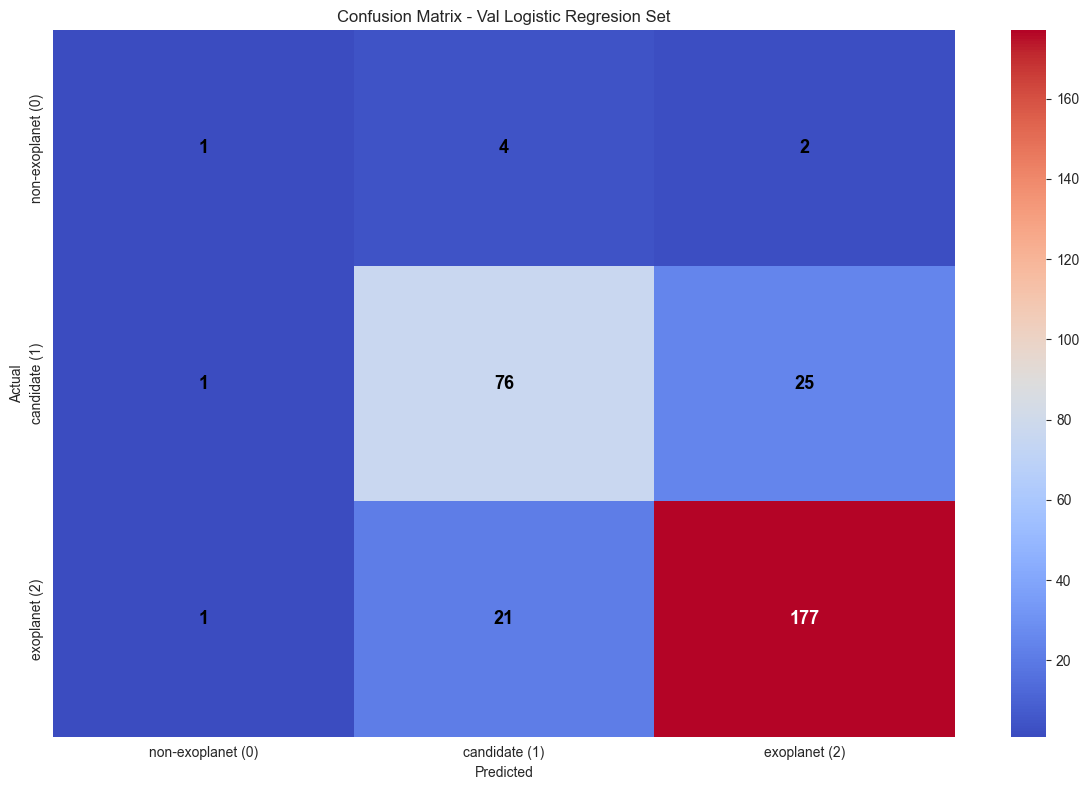

In [23]:
conf_matrix_log_val = confusion_matrix(y_val, y_val_pred_log)

plt.figure(figsize=(12, 8))

labels = [
    "non-exoplanet (0)",
    "candidate (1)",
    "exoplanet (2)"
]

ax = sns.heatmap(
    conf_matrix_log_val,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"}
)

threshold = conf_matrix_log_val.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

n_cols = conf_matrix_log_val.shape[1]
middle_index = 1 * n_cols + 1  # row * n_cols + col
ax.texts[middle_index].set_color("black")

plt.title("Confusion Matrix - Val Logistic Regresion Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

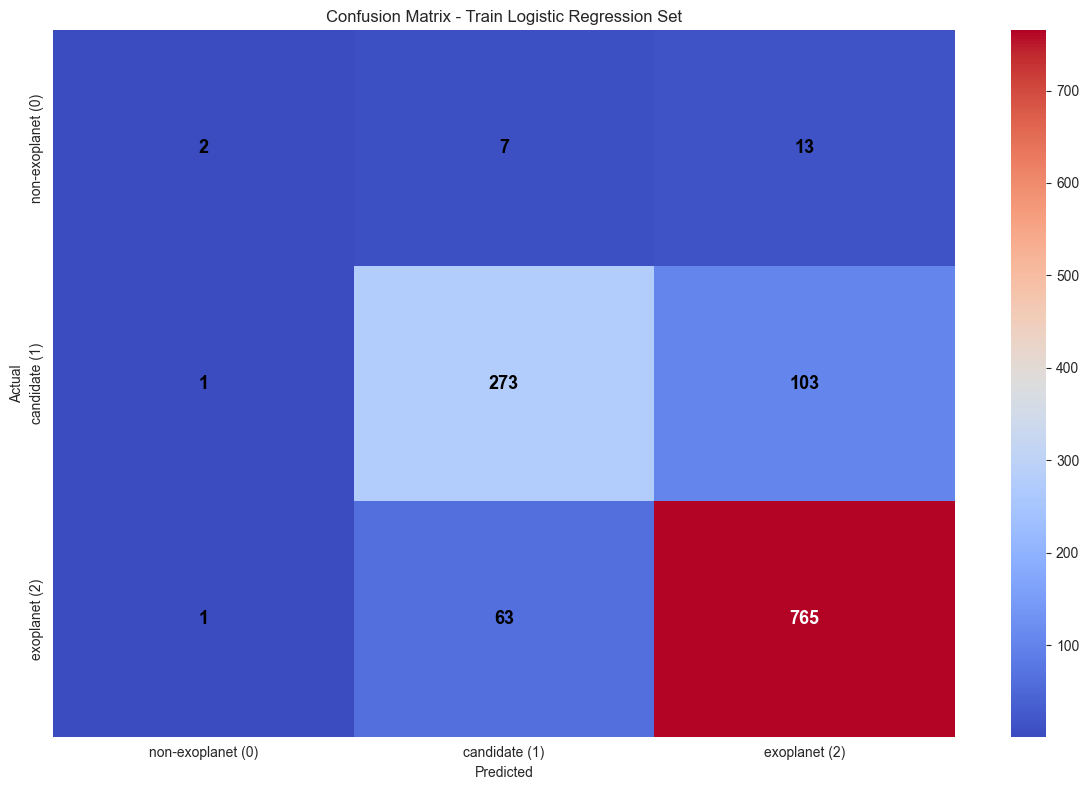

In [24]:
y_pred_log_train = log_model.predict(X_train)
conf_matrix_log_train = confusion_matrix(y_train, y_pred_log_train)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    conf_matrix_log_train,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"}
)

threshold = conf_matrix_log_train.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

n_cols = conf_matrix_log_train.shape[1]
middle_index = 1 * n_cols + 1  # row * n_cols + col
ax.texts[middle_index].set_color("black")

plt.title("Confusion Matrix - Train Logistic Regression Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Confusion Matrix for SVM

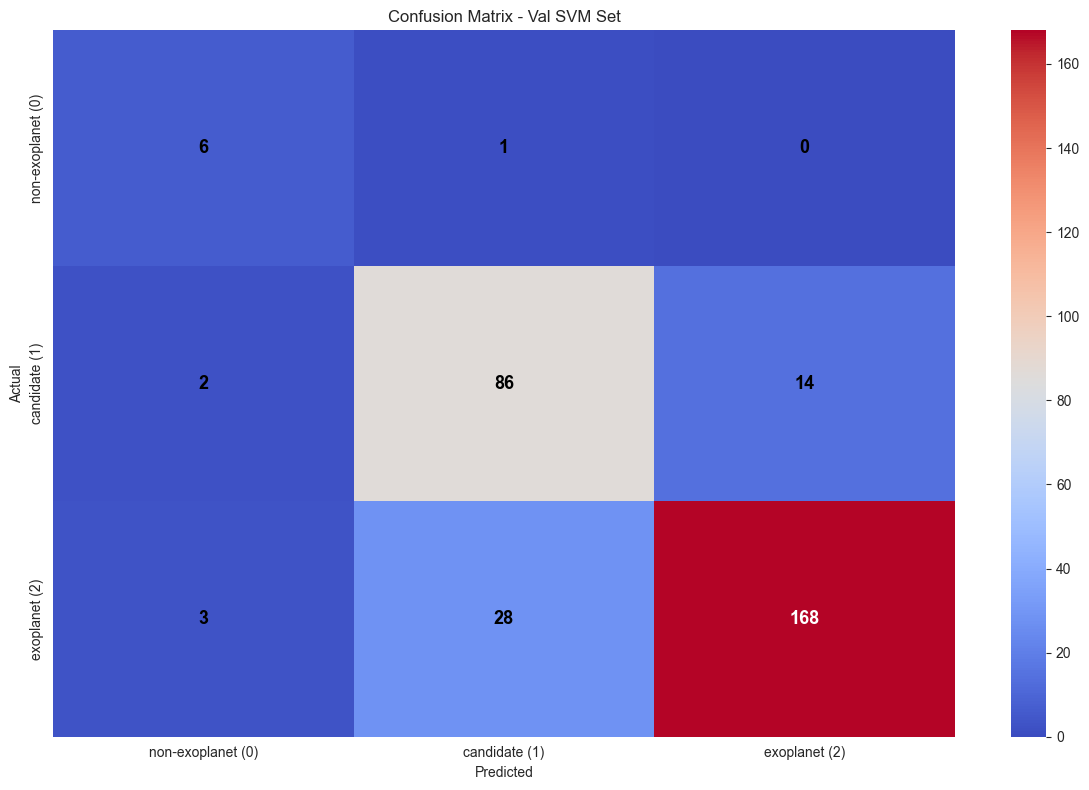

In [25]:
conf_matrix_svm_val = confusion_matrix(y_val, y_pred_svm_val)

plt.figure(figsize=(12, 8))

labels = [
    "non-exoplanet (0)",
    "candidate (1)",
    "exoplanet (2)"
]

ax = sns.heatmap(
    conf_matrix_svm_val,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"}
)

threshold = conf_matrix_svm_val.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

n_cols = conf_matrix_svm_val.shape[1]
middle_index = 1 * n_cols + 1  # row * n_cols + col
ax.texts[middle_index].set_color("black")

plt.title("Confusion Matrix - Val SVM Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

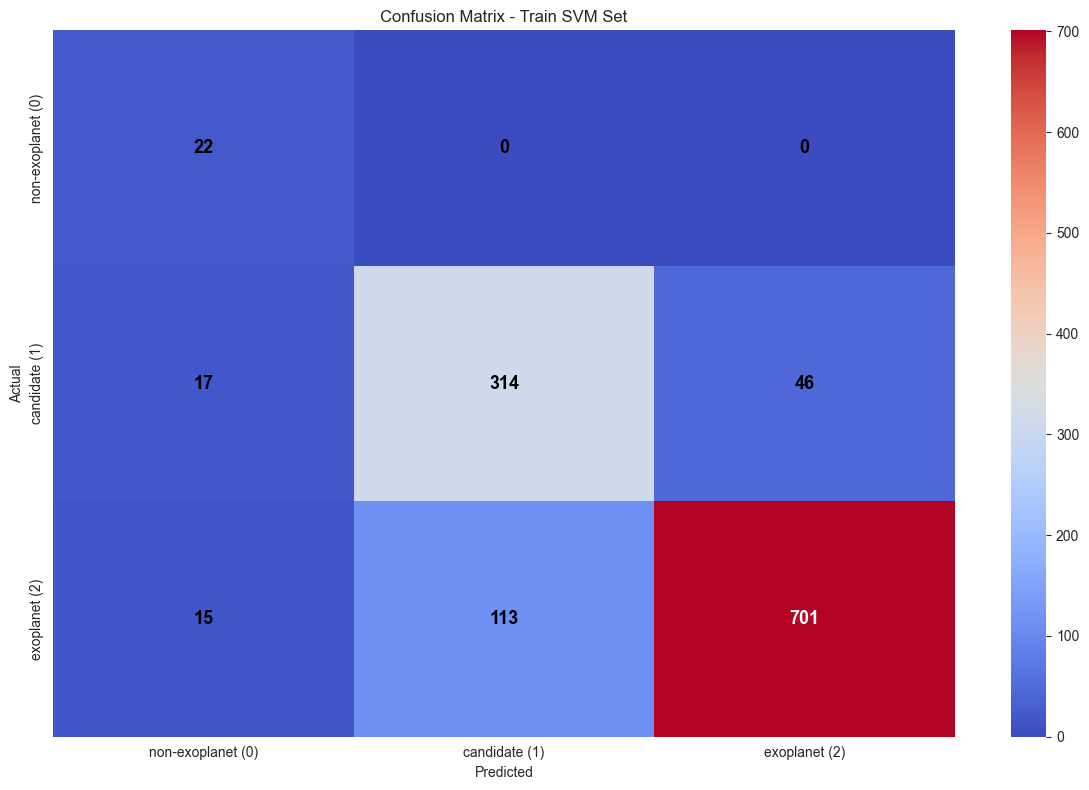

In [26]:
y_pred_svm_train = svm_model.predict(X_train)
conf_matrix_svm_train = confusion_matrix(y_train, y_pred_svm_train)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    conf_matrix_svm_train,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"}
)

threshold = conf_matrix_svm_train.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

n_cols = conf_matrix_svm_train.shape[1]
middle_index = 1 * n_cols + 1  # row * n_cols + col
ax.texts[middle_index].set_color("black")

plt.title("Confusion Matrix - Train SVM Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Final now with the test for both model

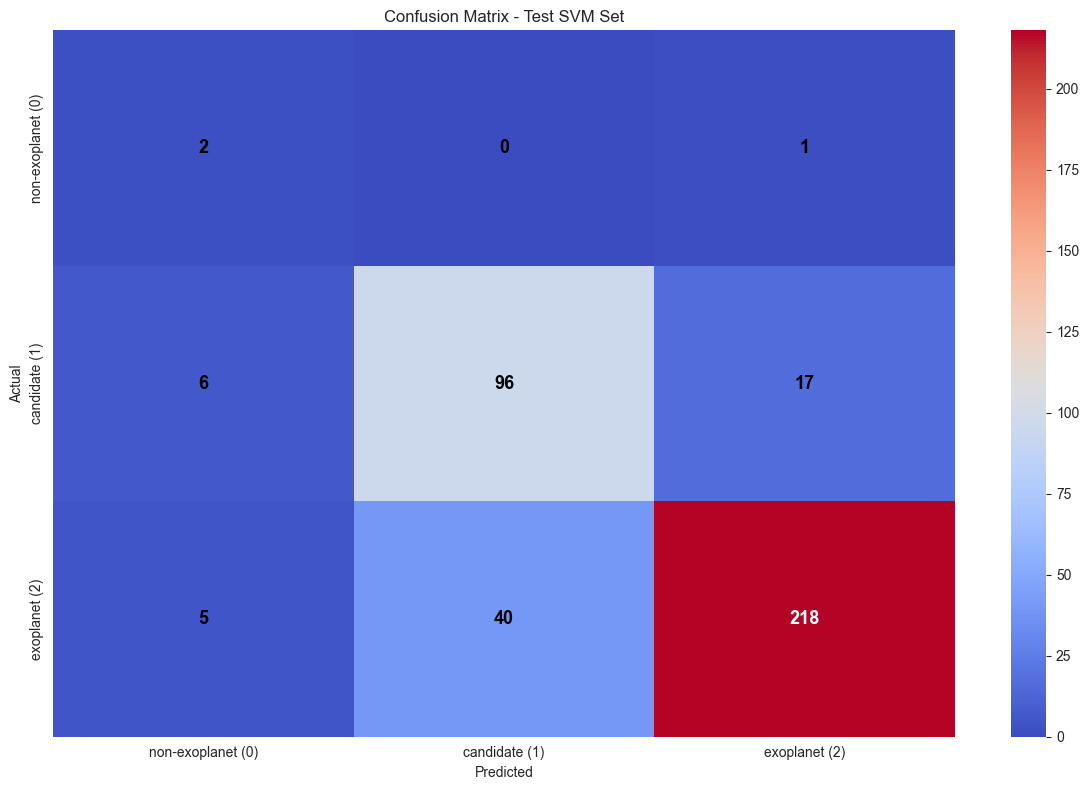

In [27]:
# SVM
y_pred_svm_test = svm_model.predict(X_test)
conf_matrix_svm_test = confusion_matrix(y_test, y_pred_svm_test)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    conf_matrix_svm_test,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"}
)

threshold = conf_matrix_svm_test.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

n_cols = conf_matrix_svm_test.shape[1]
middle_index = 1 * n_cols + 1  # row * n_cols + col
ax.texts[middle_index].set_color("black")

plt.title("Confusion Matrix - Test SVM Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [28]:
print("Validation accuracy:", accuracy_score(y_test, y_pred_svm_test))

print("\nClassification report:")
print(classification_report(y_test, y_pred_svm_test))

Validation accuracy: 0.8207792207792208

Classification report:
              precision    recall  f1-score   support

           0       0.15      0.67      0.25         3
           1       0.71      0.81      0.75       119
           2       0.92      0.83      0.87       263

    accuracy                           0.82       385
   macro avg       0.59      0.77      0.63       385
weighted avg       0.85      0.82      0.83       385



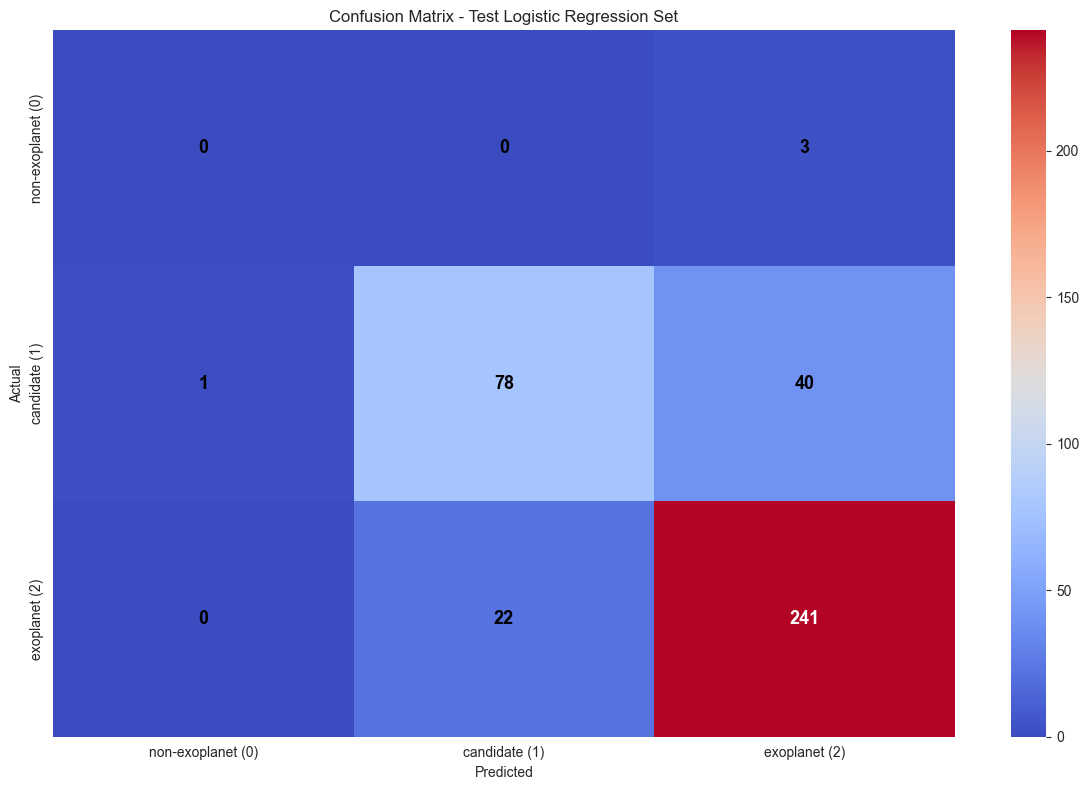

In [29]:
# Logistic Regression
y_pred_log_test = log_model.predict(X_test)
conf_matrix_log_test = confusion_matrix(y_test, y_pred_log_test)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    conf_matrix_log_test,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 13, "weight": "bold"}
)

threshold = conf_matrix_log_test.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "black")

n_cols = conf_matrix_log_test.shape[1]
middle_index = 1 * n_cols + 1  # row * n_cols + col
ax.texts[middle_index].set_color("black")

plt.title("Confusion Matrix - Test Logistic Regression Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [30]:
print("Validation accuracy:", accuracy_score(y_test, y_pred_log_test))

print("\nClassification report:")
print(classification_report(y_test, y_pred_log_test))

Validation accuracy: 0.8285714285714286

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.78      0.66      0.71       119
           2       0.85      0.92      0.88       263

    accuracy                           0.83       385
   macro avg       0.54      0.52      0.53       385
weighted avg       0.82      0.83      0.82       385



## Final conclusion

This assignment focused on multiclass classification of exoplanet observations.

I prepared the data by removing irrelevant identifier columns, handling missing values, checking outliers, removing selected correlated or low-variation features, transforming skewed numerical features and scaling the data.

I trained two models:
- Logistic Regression
- Support Vector Machine with RBF kernel

Logistic Regression was used as a simple baseline model.  
SVM was used because it can create non-linear decision boundaries using kernels.

Because the dataset has multiple classes and possible class imbalance, accuracy alone is not enough.  
I also used precision, recall, F1 score and confusion matrices.

SVM used `class_weight="balanced"` to help with class imbalance.

A limitation is that exoplanet classification is complex, and the model performance depends strongly on preprocessing, feature selection and class balance. A possible improvement would be to tune hyperparameters with grid search or try other models.